In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error

BASE_DIR = Path("C:/Users/VSB-AIDSPC20/Downloads/demand forecating")
DATA_PATH = BASE_DIR / "data" / "processed" / "clean_sales.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df = df.sort_values(["store", "item", "date"]).reset_index(drop=True)

In [2]:
ts = df[(df["store"] == 1) & (df["item"] == 1)].copy()
ts = ts.set_index("date")
ts = ts["sales"]


In [3]:
train = ts[: "2016-12-31"]
test  = ts["2017-01-01":]

print(len(train), len(test))


1461 365


In [5]:
naive_forecast = np.repeat(train.iloc[-1], len(test))

mae_naive = mean_absolute_error(test, naive_forecast)
rmse_naive = np.sqrt(mean_squared_error(test, naive_forecast))

mae_naive, rmse_naive


(8.758904109589041, np.float64(10.732488125773212))

In [6]:
WINDOW = 7
ma_value = train.rolling(WINDOW).mean().iloc[-1]

ma_forecast = np.repeat(ma_value, len(test))

mae_ma = mean_absolute_error(test, ma_forecast)
rmse_ma = np.sqrt(mean_squared_error(test, ma_forecast))

mae_ma, rmse_ma


(6.706849315068494, np.float64(8.497324810483688))

In [7]:
baseline_results = pd.DataFrame({
    "Model": ["Naive", "Moving Average (7)"],
    "MAE": [mae_naive, mae_ma],
    "RMSE": [rmse_naive, rmse_ma]
})

baseline_results


,Model,MAE,RMSE
0,Naive,8.758904,10.732488
1,Moving Average (7),6.706849,8.497325


In [11]:
!pip install statsmodels


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.5 MB 8.5 MB/s eta 0:00:02
   ---------------------------------------- 9.5/9.5 MB 33.0 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\VSB-AIDSPC20\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [12]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train, order=(1, 1, 1))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(test))

mae_arima = mean_absolute_error(test, arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(test, arima_forecast))

mae_arima, rmse_arima


C:\Users\VSB-AIDSPC20\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\VSB-AIDSPC20\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\VSB-AIDSPC20\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


(6.7814217276254745, np.float64(8.595241276446409))

In [13]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train, order=(1, 1, 1))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(test))

mae_arima = mean_absolute_error(test, arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(test, arima_forecast))

mae_arima, rmse_arima


C:\Users\VSB-AIDSPC20\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\VSB-AIDSPC20\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\VSB-AIDSPC20\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


(6.7814217276254745, np.float64(8.595241276446409))

In [14]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)
sarima_forecast = sarima_fit.forecast(len(test))

mae_sarima = mean_absolute_error(test, sarima_forecast)
rmse_sarima = np.sqrt(mean_squared_error(test, sarima_forecast))

mae_sarima, rmse_sarima


C:\Users\VSB-AIDSPC20\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\VSB-AIDSPC20\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


(6.016204912914889, np.float64(7.5875325691165365))

In [15]:
results = pd.DataFrame({
    "Model": [
        "Naive",
        "Moving Avg (7)",
        "ARIMA(1,1,1)",
        "SARIMA(1,1,1)(1,1,1,7)"
    ],
    "MAE": [
        mae_naive,
        mae_ma,
        mae_arima,
        mae_sarima
    ],
    "RMSE": [
        rmse_naive,
        rmse_ma,
        rmse_arima,
        rmse_sarima
    ]
})

results


,Model,MAE,RMSE
0,Naive,8.758904,10.732488
1,Moving Avg (7),6.706849,8.497325
2,"ARIMA(1,1,1)",6.781422,8.595241
3,"SARIMA(1,1,1)(1,1,1,7)",6.016205,7.587533


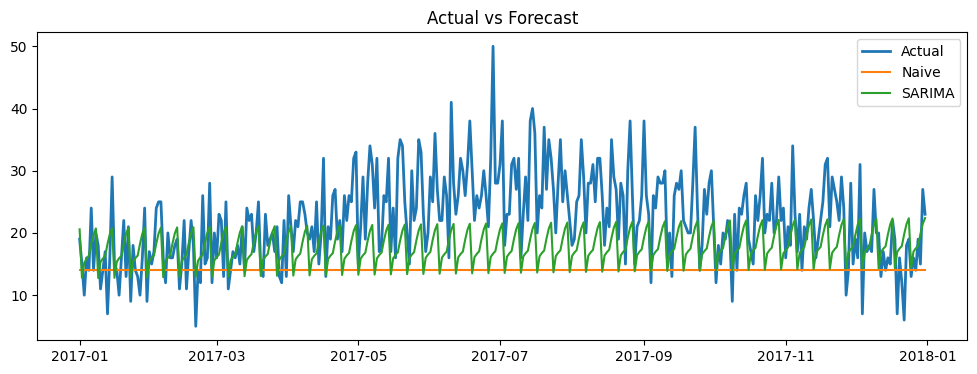

In [16]:
plt.figure(figsize=(12,4))
plt.plot(test.index, test.values, label="Actual", linewidth=2)
plt.plot(test.index, naive_forecast, label="Naive")
plt.plot(test.index, sarima_forecast, label="SARIMA")
plt.legend()
plt.title("Actual vs Forecast")
plt.show()
